In [1]:
import collections
import itertools
import os
import pickle
import sys
import time
from itertools import combinations_with_replacement

import freud
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
import pandas
import seaborn as sns
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from chroma import structure

plt.style.use("/home/mm146/chroma/chroma/paper.mplstyle")

# Single chromosome simulation


In [2]:
NUM_REPLICAS = 32
DATA_FOLDER = "/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/4_analysis/polarization/data"

## control


In [3]:
control_dipole_moment = []
control_dipole_magnitude = []
for replica in range(1, NUM_REPLICAS + 1):
    with h5py.File(
        f"{DATA_FOLDER}/control/polarization-replica{replica}.h5"
    ) as saved_file:
        control_dipole_moment.append(saved_file["dipole_moment"][()])

        control_dipole_magnitude.append(
            saved_file["dipole_magnitude"][()]
        )

In [4]:
control_dipole_moment = np.concatenate(control_dipole_moment, axis=0)
control_dipole_magnitude = np.concatenate(
    control_dipole_magnitude, axis=0
)

## complete


In [5]:
complete_dipole_moment = []
complete_dipole_magnitude = []
for replica in range(1, NUM_REPLICAS + 1):
    with h5py.File(
        f"{DATA_FOLDER}/complete/polarization-replica{replica}.h5"
    ) as saved_file:
        complete_dipole_moment.append(saved_file["dipole_moment"][()])

        complete_dipole_magnitude.append(
            saved_file["dipole_magnitude"][()]
        )

In [6]:
complete_dipole_moment = np.concatenate(
    complete_dipole_moment, axis=0
)
complete_dipole_magnitude = np.concatenate(
    complete_dipole_magnitude, axis=0
)

## lamina


In [7]:
lamina_dipole_moment = []
lamina_dipole_magnitude = []
for replica in range(1, NUM_REPLICAS + 1):
    with h5py.File(
        f"{DATA_FOLDER}/lamina/polarization-replica{replica}.h5"
    ) as saved_file:
        lamina_dipole_moment.append(saved_file["dipole_moment"][()])

        lamina_dipole_magnitude.append(
            saved_file["dipole_magnitude"][()]
        )

In [8]:
lamina_dipole_moment = np.concatenate(lamina_dipole_moment, axis=0)
lamina_dipole_magnitude = np.concatenate(
    lamina_dipole_magnitude, axis=0
)

## nucleolus


In [10]:
nucleolus_dipole_moment = []
nucleolus_dipole_magnitude = []
for replica in range(1, NUM_REPLICAS + 1):
    with h5py.File(
        f"{DATA_FOLDER}/nucleolus/polarization-replica{replica}.h5"
    ) as saved_file:
        nucleolus_dipole_moment.append(
            saved_file["dipole_moment"][()]
        )

        nucleolus_dipole_magnitude.append(
            saved_file["dipole_magnitude"][()]
        )

In [11]:
nucleolus_dipole_moment = np.concatenate(
    nucleolus_dipole_moment, axis=0
)
nucleolus_dipole_magnitude = np.concatenate(
    nucleolus_dipole_magnitude, axis=0
)

## plotting


Text(0, 0.5, 'Probability density')

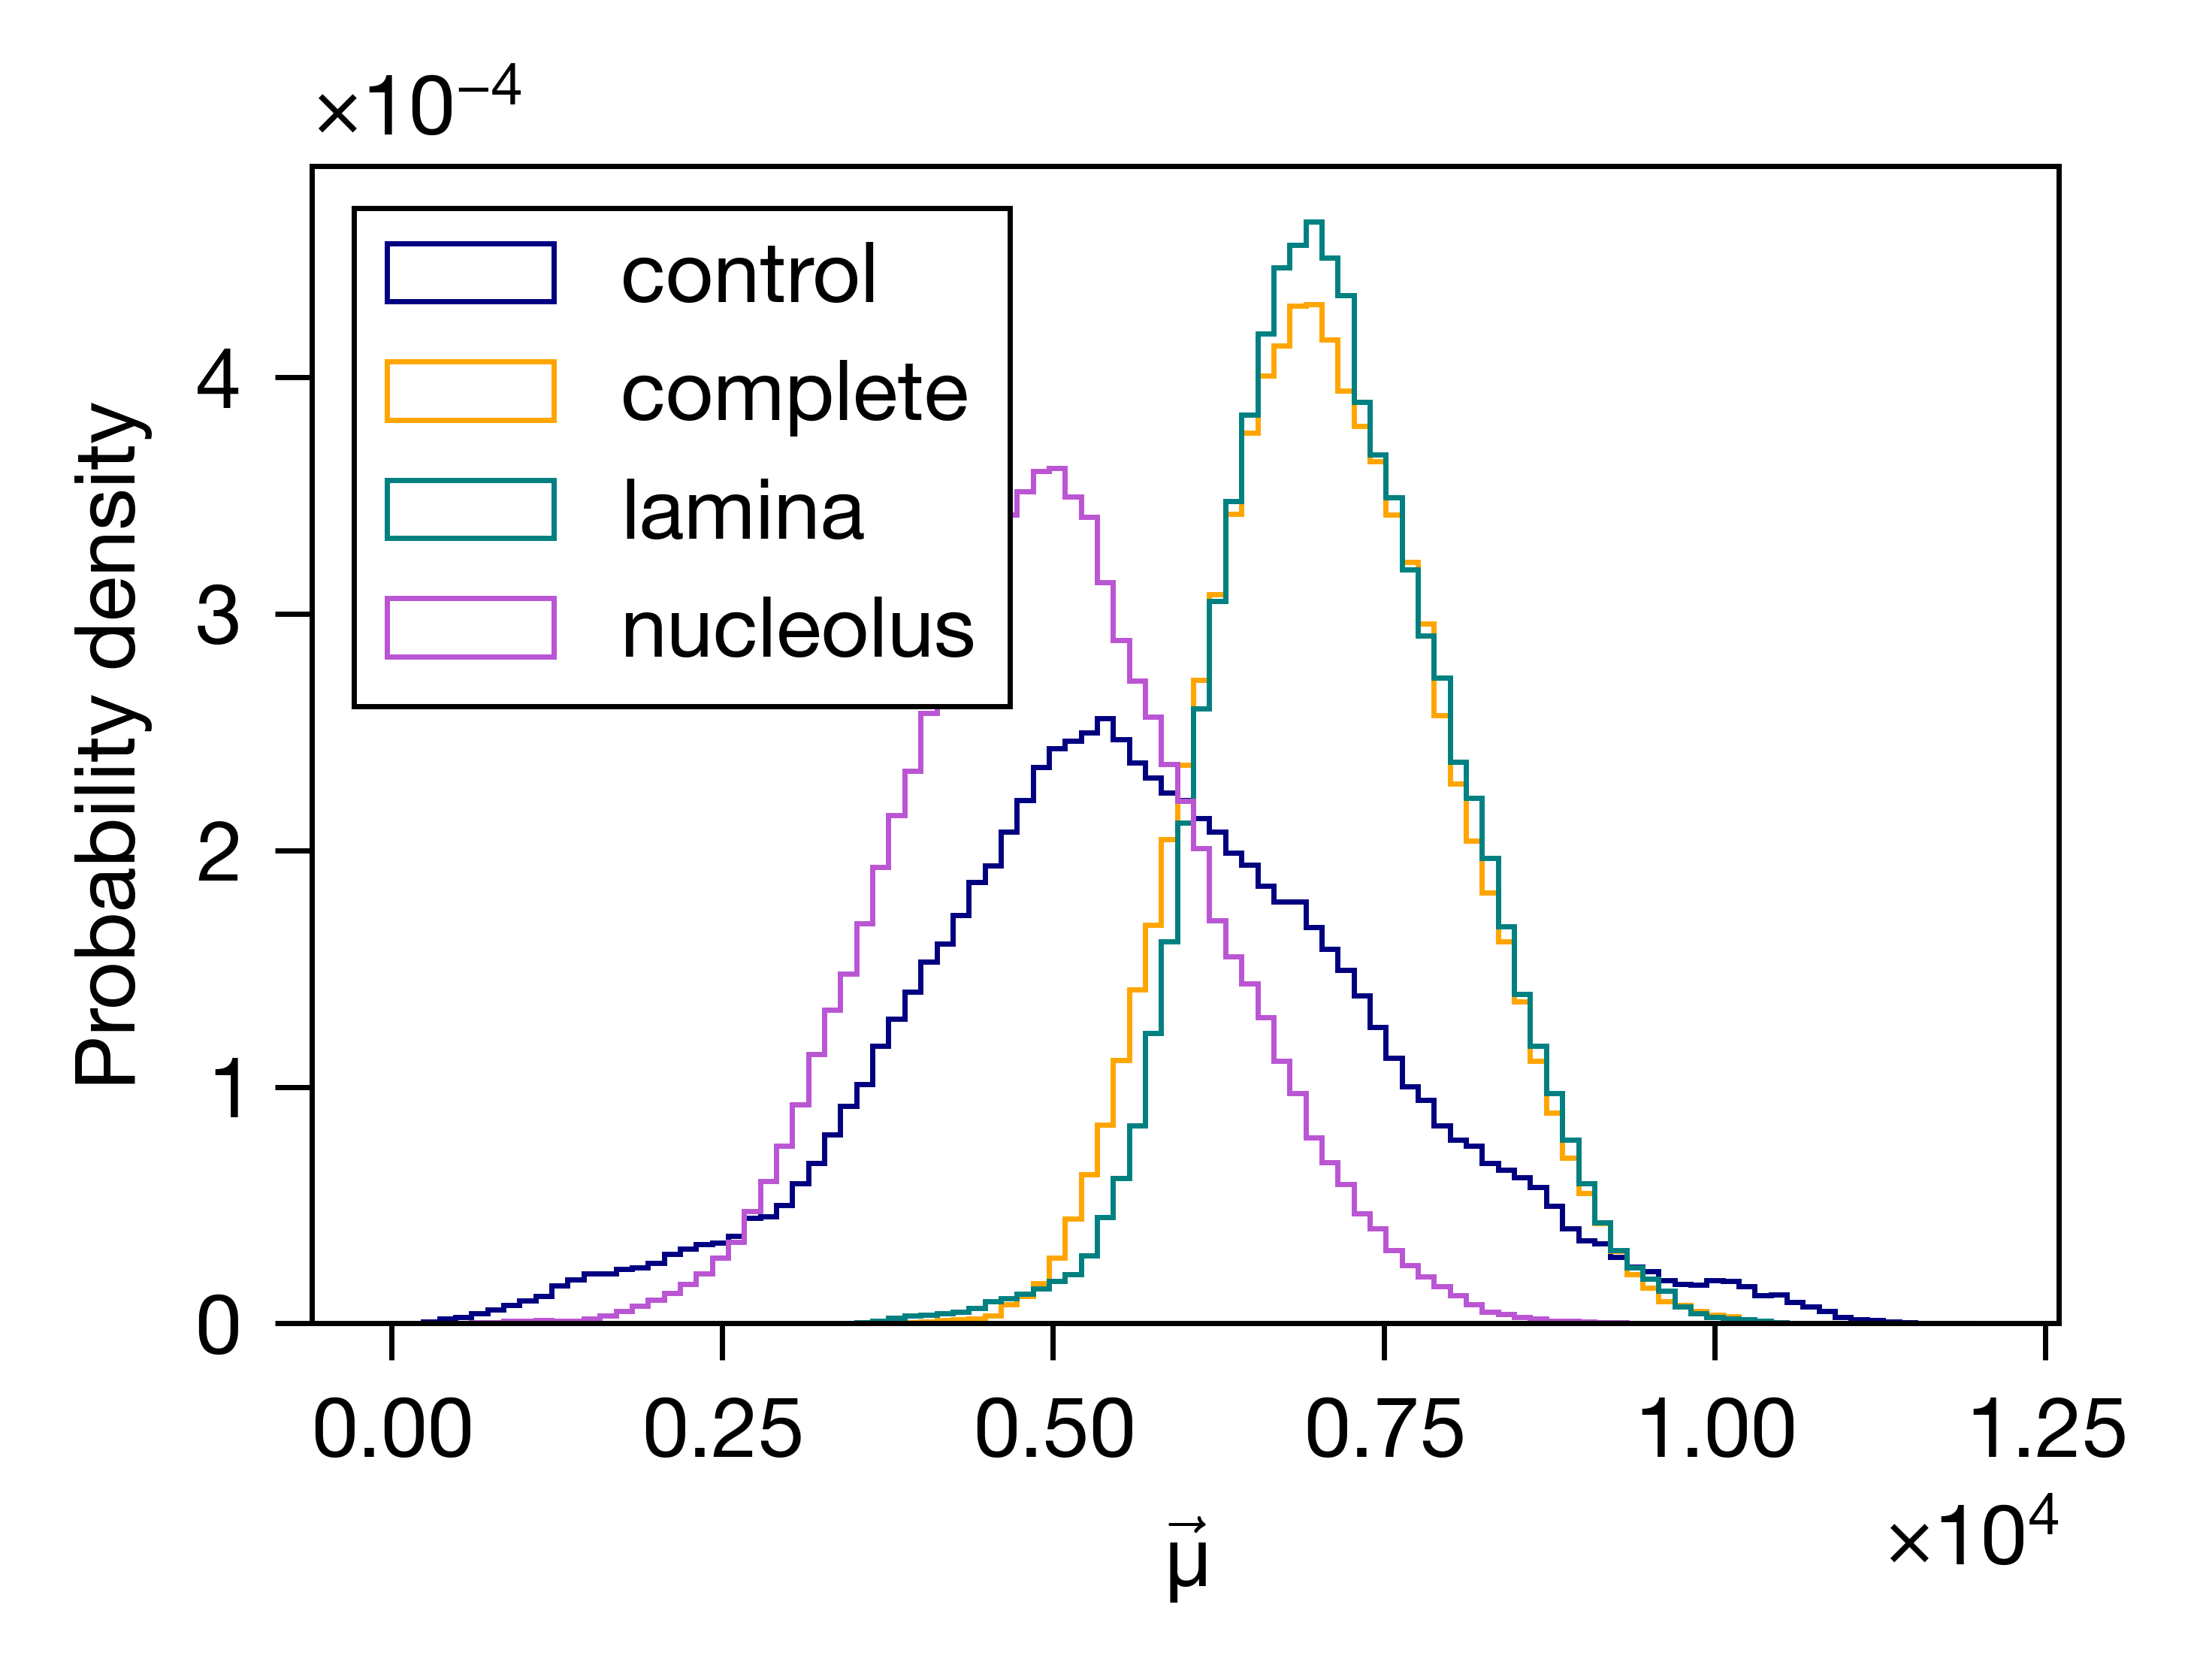

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

ax.hist(
    control_dipole_magnitude,
    bins=np.linspace(0, 12e3, 100),
    label="control",
    histtype="step",
    density=True,
)
ax.hist(
    complete_dipole_magnitude,
    bins=np.linspace(0, 12e3, 100),
    label="complete",
    histtype="step",
    density=True,
)
ax.hist(
    lamina_dipole_magnitude,
    bins=np.linspace(0, 12e3, 100),
    label="lamina",
    histtype="step",
    density=True,
)
ax.hist(
    nucleolus_dipole_magnitude,
    bins=np.linspace(0, 12e3, 100),
    label="nucleolus",
    histtype="step",
    density=True,
)

ax.legend(
    # bbox_to_anchor=(1.0, 1.036)
)

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

ax.yaxis.set_major_formatter(formatter)
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel(r"$\vec \mu$")
ax.set_ylabel("Probability density")

Text(0, 0.5, 'Probability density')

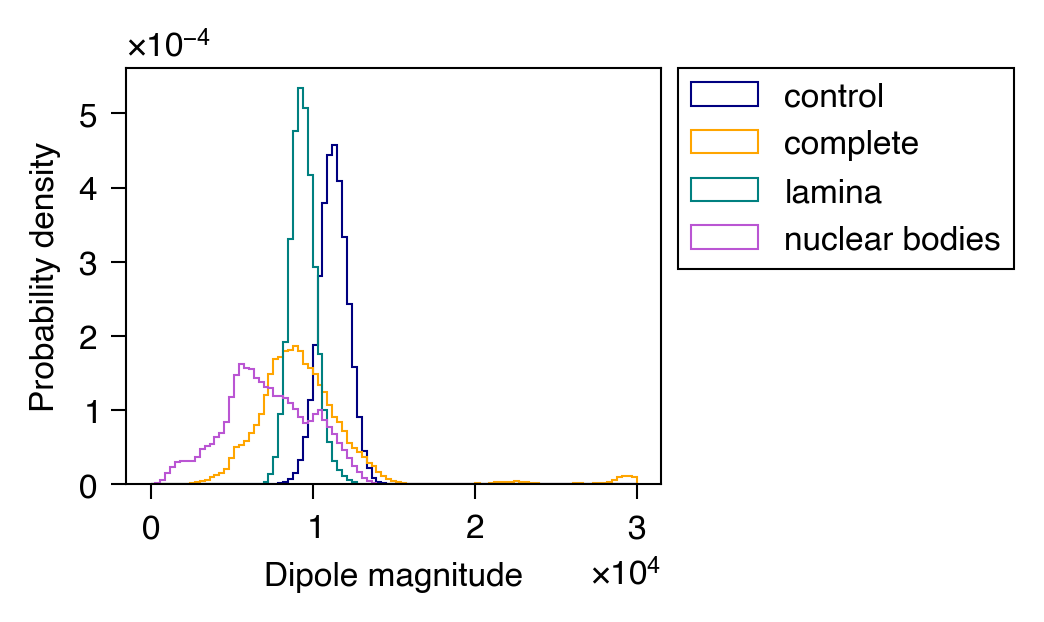

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

ax.hist(
    control_dipole_magnitude,
    bins=np.linspace(0, 30000, 100),
    label="control",
    histtype="step",
    density=True,
)
ax.hist(
    complete_dipole_magnitude,
    bins=np.linspace(0, 30000, 100),
    label="complete",
    histtype="step",
    density=True,
)
ax.hist(
    lamina_dipole_magnitude,
    bins=np.linspace(0, 30000, 100),
    label="lamina",
    histtype="step",
    density=True,
)
# ax.hist(
#     nucleolus_dipole_magnitude,
#     bins=np.linspace(0, 30000, 100),
#     label="nucleolus",
#     histtype="step",
#     density=True,
# )
# ax.hist(
#     isolation_dipole_magnitude,
#     bins=np.linspace(0, 30000, 100),
#     label="isolation",
#     histtype="step",
#     density=True,
# )
ax.hist(
    nuclear_bodies_dipole_magnitude,
    bins=np.linspace(0, 30000, 100),
    label="nuclear bodies",
    histtype="step",
    density=True,
)

ax.legend(bbox_to_anchor=(1.0, 1.04))

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.yaxis.set_major_formatter(formatter)
ax.xaxis.set_major_formatter(formatter)


ax.set_xlabel(r"Dipole magnitude")
# ax.set_xlabel(r"$\vec \mu$")
ax.set_ylabel("Probability density")

In [20]:
histograms_chr10_single_chr = {
    "control": np.histogram(
        control_dipole_magnitude,
        bins=np.linspace(0, 30000, 100),
        density=True,
    ),
    "complete": np.histogram(
        complete_dipole_magnitude,
        bins=np.linspace(0, 30000, 100),
        density=True,
    ),
    "lamina": np.histogram(
        lamina_dipole_magnitude,
        bins=np.linspace(0, 30000, 100),
        density=True,
    ),
    "nuclear_bodies": np.histogram(
        nuclear_bodies_dipole_magnitude,
        bins=np.linspace(0, 30000, 100),
        density=True,
    ),
}

Text(0, 0.5, 'Probability density')

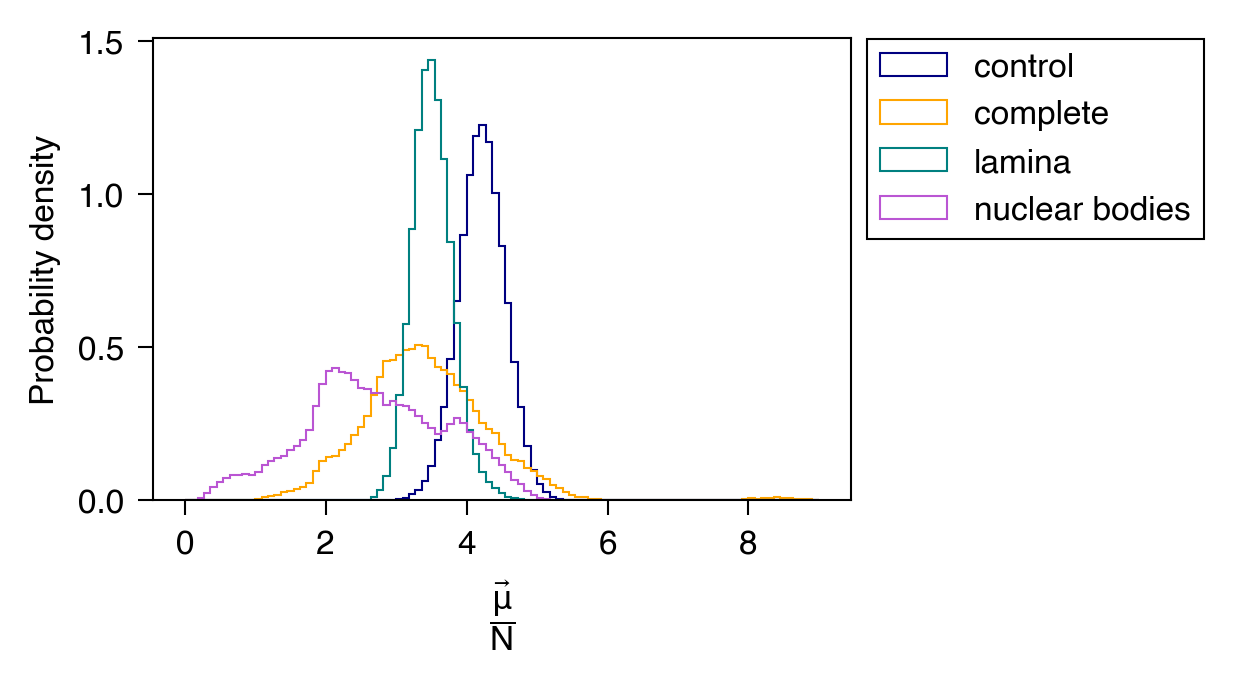

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

bins = np.linspace(0, 9, 100)

ax.hist(
    control_dipole_magnitude / chr10_size,
    bins=bins,
    label="control",
    histtype="step",
    density=True,
)
ax.hist(
    complete_dipole_magnitude / chr10_size,
    bins=bins,
    label="complete",
    histtype="step",
    density=True,
)
ax.hist(
    lamina_dipole_magnitude / chr10_size,
    bins=bins,
    label="lamina",
    histtype="step",
    density=True,
)
ax.hist(
    nuclear_bodies_dipole_magnitude / chr10_size,
    bins=bins,
    label="nuclear bodies",
    histtype="step",
    density=True,
)

ax.legend(loc="upper right", bbox_to_anchor=(1.53, 1.036))

ax.set_xlabel(r"$\dfrac{\vec \mu}{N}$")
ax.set_ylabel("Probability density")

# paper figure


In [77]:
colors = sns.color_palette("rocket", 4)

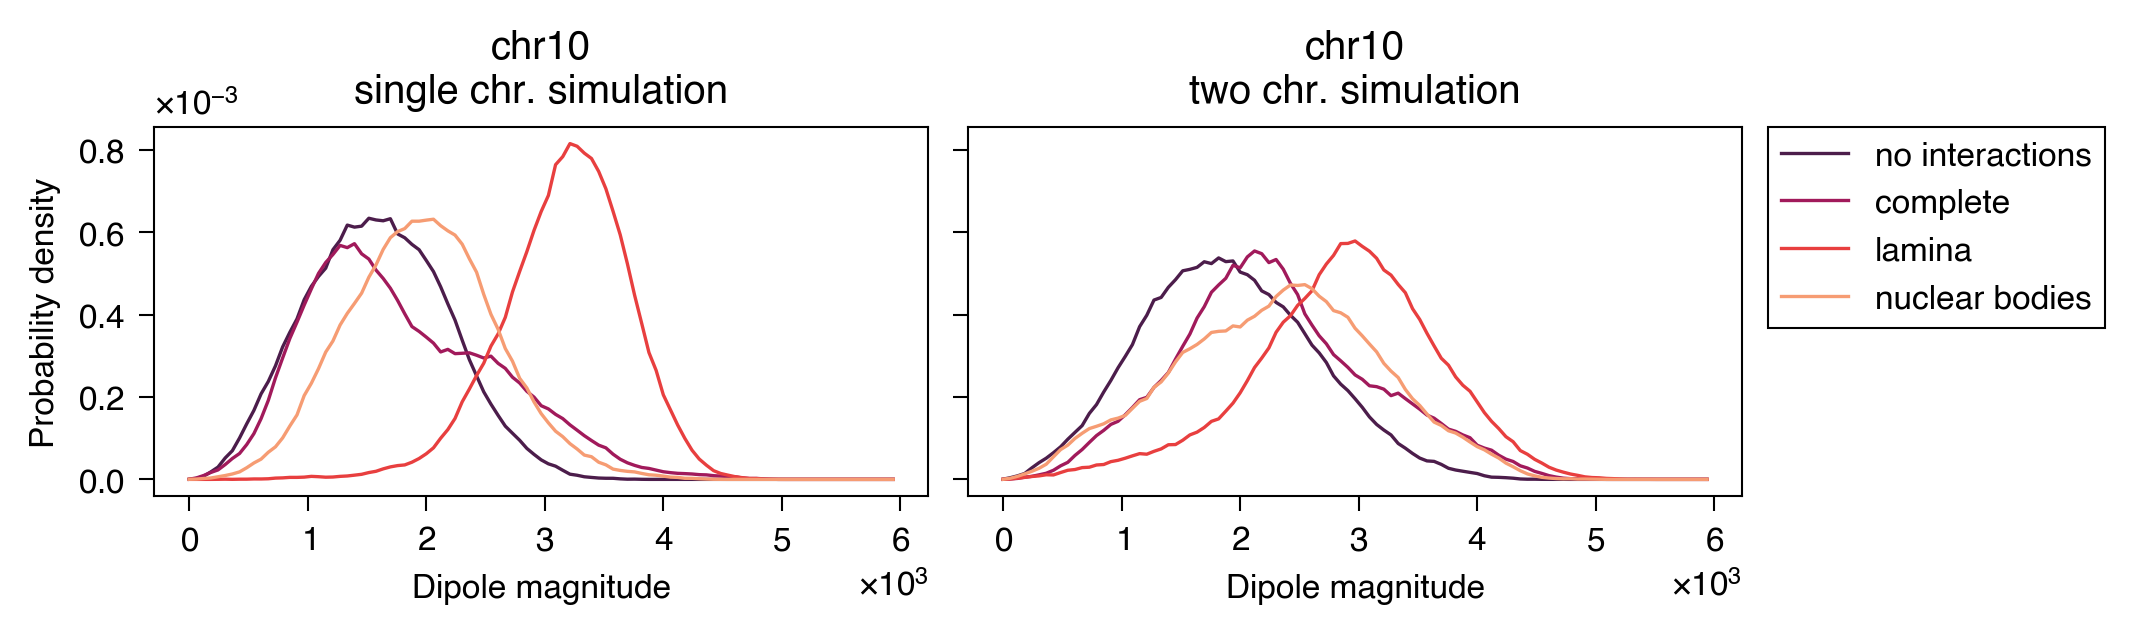

In [123]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(7, 2),
    sharex=True,
    sharey=True,
    layout="constrained",
)

## single chr simulation

ax[0].plot(
    histograms_chr10_single_chr["control"][1][:-1],
    histograms_chr10_single_chr["control"][0],
    label=r"no nb. interactions",
    color=colors[0],
)
ax[0].plot(
    histograms_chr10_single_chr["complete"][1][:-1],
    histograms_chr10_single_chr["complete"][0],
    label="complete",
    color=colors[1],
)
ax[0].plot(
    histograms_chr10_single_chr["lamina"][1][:-1],
    histograms_chr10_single_chr["lamina"][0],
    label="lamina",
    color=colors[2],
)
ax[0].plot(
    histograms_chr10_single_chr["nuclear_bodies"][1][:-1],
    histograms_chr10_single_chr["nuclear_bodies"][0],
    label="nuclear bodies",
    color=colors[3],
)

ax[1].plot(
    histograms_chr10_two_chr["control"][1][:-1],
    histograms_chr10_two_chr["control"][0],
    label=r"no interactions",
    color=colors[0],
)
ax[1].plot(
    histograms_chr10_two_chr["complete"][1][:-1],
    histograms_chr10_two_chr["complete"][0],
    label="complete",
    color=colors[1],
)
ax[1].plot(
    histograms_chr10_two_chr["lamina"][1][:-1],
    histograms_chr10_two_chr["lamina"][0],
    label="lamina",
    color=colors[2],
)
ax[1].plot(
    histograms_chr10_two_chr["nuclear_bodies"][1][:-1],
    histograms_chr10_two_chr["nuclear_bodies"][0],
    label="nuclear bodies",
    color=colors[3],
)

ax[1].legend(bbox_to_anchor=(1.49, 1.045))

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax[0].yaxis.set_major_formatter(formatter)
ax[0].xaxis.set_major_formatter(formatter)
ax[1].xaxis.set_major_formatter(formatter)


ax[0].set_xlabel(r"Dipole magnitude")
ax[1].set_xlabel(r"Dipole magnitude")
# ax[0].set_xlabel(r"$\vec \mu$")
ax[0].set_ylabel("Probability density")

ax[0].set_title("chr10\nsingle chr. simulation")
ax[1].set_title("chr10\ntwo chr. simulation")

fig.savefig("fig-dipole-magnitude-simulation.pdf")

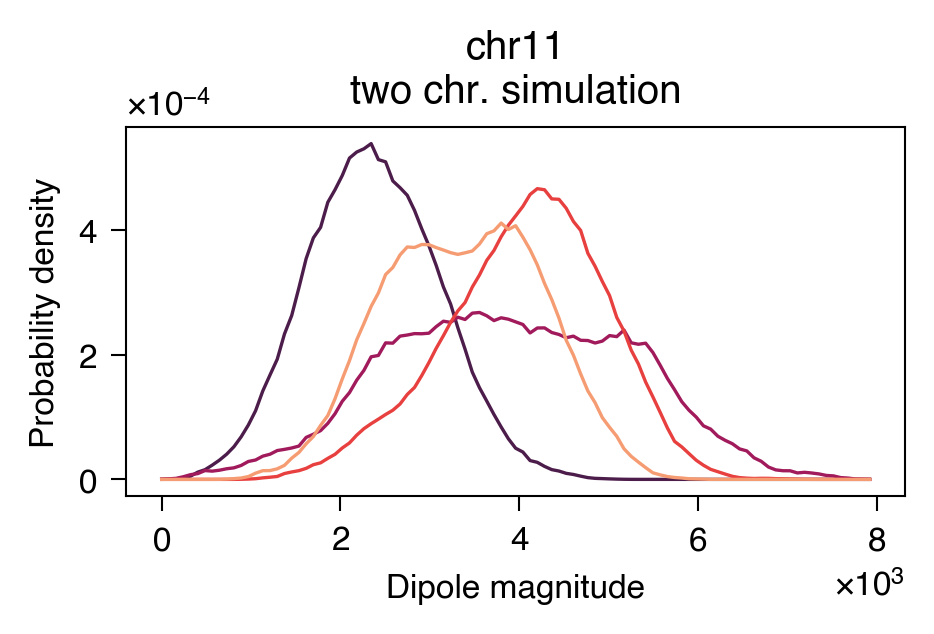

In [142]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(3, 2),
    sharex=True,
    sharey=True,
    layout="constrained",
)

## single chr simulation

ax.plot(
    histograms_chr11_two_chr["control"][1][:-1],
    histograms_chr11_two_chr["control"][0],
    label=r"no interactions",
    color=colors[0],
)
ax.plot(
    histograms_chr11_two_chr["complete"][1][:-1],
    histograms_chr11_two_chr["complete"][0],
    label="complete",
    color=colors[1],
)
ax.plot(
    histograms_chr11_two_chr["lamina"][1][:-1],
    histograms_chr11_two_chr["lamina"][0],
    label="lamina",
    color=colors[2],
)
ax.plot(
    histograms_chr11_two_chr["nuclear_bodies"][1][:-1],
    histograms_chr11_two_chr["nuclear_bodies"][0],
    label="nuclear bodies",
    color=colors[3],
)

# ax.legend(bbox_to_anchor=(1.49, 1.045))

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.yaxis.set_major_formatter(formatter)
ax.xaxis.set_major_formatter(formatter)
ax.xaxis.set_major_formatter(formatter)


ax.set_xlabel(r"Dipole magnitude")
ax.set_xlabel(r"Dipole magnitude")
# ax.set_xlabel(r"$\vec \mu$")
ax.set_ylabel("Probability density")

ax.set_title("chr11\ntwo chr. simulation")

fig.savefig("fig-dipole-magnitude-simulation-chr11.pdf")